In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Estimating Diffusivity and Reaction Coefficient

## General Domain Description

Water quality modeling is concerned with describing and predicting the **transport and transformation of substances in water systems**. These substances can be chlorine, nutrients, pollutants, sediments, dissolved oxygen, or other chemical and biological constituents that influence ecosystem health and water usability.

We approximate the domain of a pipe of length $L = 100[m]$ as a 1-dimensional space. Therefore, $x \in (0, L)$
We model this on a 1-dimensional domain of length $L = 100[m]$, over a time period of $T = 100[s]$.

## PINN Example: Advection-Diffusion-Reaction

In the water quality domain, the Advection-Diffusion-Reaction PDE (ADR) is very important. It models three dynamics at the same time:
  1. **A**dvection: The transport of a substance in the presence of a flow field.
  2. **D**iffusion/Dispersion: Spread of the substance due to additional effects (turbulence, eddy currents, molecular motion)
  3. **R**eaction: Chemical reactions and decay of substances

The PDE is as follows:

$$
\frac{\partial u}{\partial t} = -v \frac{\partial u}{\partial x} + D \frac{\partial^2 u}{\partial x^2} - ku
$$


## Task Description:

 * No knowledge of diffusivity $D$ and reaction coefficient $k$.
 * Left boundary (Injection point) known
 * A sensor at the right (outflow) boundary, also known

**Problem:** Without $D$ and $k$, we cannot compute the PDE loss:

$$\mathcal{L}_{PDE}(x, t) = \left(
u_t(x, t) + v u_x(x, t) - {\color{#6699ee}D} u_{xx}(x, t) + {\color{#6699ee}k}u(x, t)
\right)^2
$$

**Solution:** Jointly learn the parameters $D$, and $k$.

**What we need to change:** Nothing! Just make an initial guess for $D$ and $k$ and add them to the gradient-descent optimization routine.

> We have to hope that the additional data provided by the sensor contains enough information to estimate diffusivity and reaction coefficient. We try to learn these parameters jointly with the exact PINN setup we had before. However, note that the PDE structure is still valid, but it is not as restrictive as it was when we knew $D$ and $k$.

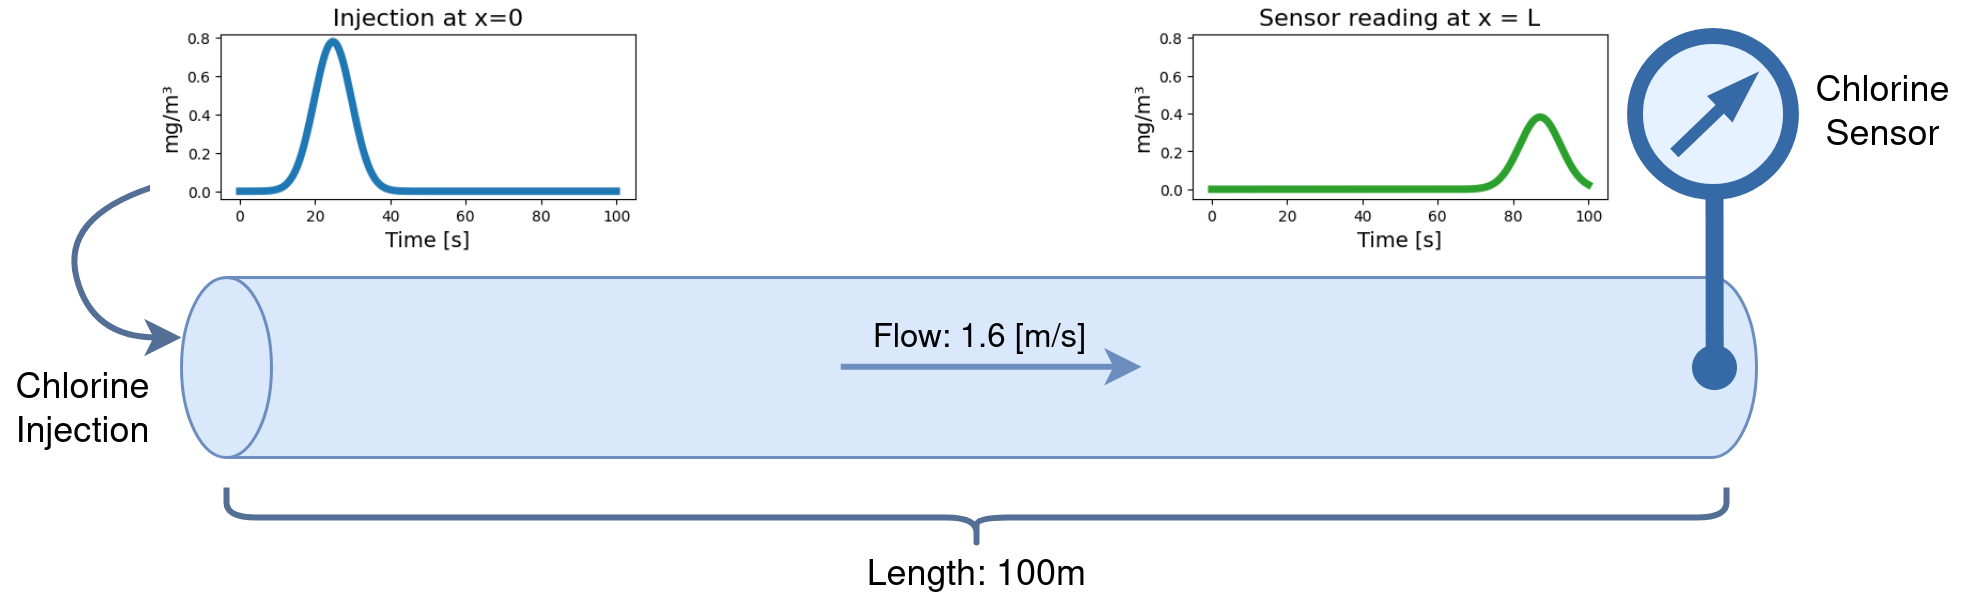

> Because of the Gaussian pulse injection we can compute an analytical solution of the system. We use it as a simple way to 'simulate' the sensor data.

In [ ]:
import matplotlib.pyplot as plt

# These are the hidden unkown coefficients
# (we only use them to generate sensor data and for
# later comparison with the learned variables):
D_true = 0.1
k_true = 0.01

# Sensor implements the analytical solution that exists because we
# inject a Gaussian pulse: Adjection is shift of the mean and diffusion is spread
# of the standard-deviation, reaction is simple first-order decay (exponential).
def sensor(x, t, v, t_peak=25, tau=5):
    t = torch.where(t == 0, 1e-10, t)
    sigma_eff = np.sqrt(tau**2 + (2 * D_true * x / v**3))
    t_travel = x / v
    decay = torch.exp(-k_true * t)
    pulse = torch.exp(-0.5 * (t - t_peak - t_travel)**2 / sigma_eff**2)
    u = (tau / sigma_eff) * decay * pulse
    u = torch.where(t < x/v - 3*tau, 0, u)
    return u

def bc_left(t):
    '''
    Boundary Condition (Dirichlet) at the left side.
    '''
    return sensor(0, t * T, flow_speed)

def bc_right(t):
    '''
    Boundary Condition (Dirichlet) at the right side.
    '''
    return sensor(L, t * T, flow_speed)

# Setup
L = 100 # [100m]
T = 100 # [sec]
flow_speed = 1.6

ts = torch.linspace(0, T, 200)
xs = torch.linspace(0, L, 200)

# Right side boundary is an outflow condition (free bounadry)
# Initial Condition is Zero, we don't need to explicitly generate this.
plt.figure(figsize=(10, 3))
plt.plot(bc_left(torch.linspace(0, 1, 200)), label='Injection')
plt.plot(bc_right(torch.linspace(0, 1, 200)), label='Sensor')
plt.title('Injection and Sensor (Left and Right Boundary)')
plt.xlabel('Time [s]')
plt.ylabel(r'Chlorine $mg/m^3$')
_ = plt.legend()

## Guess starting Diffusivity and Reaction Coefficient

In [ ]:
D_initial_guess = 0.5
k_initial_guess = 0.5

diffusion_param = nn.Parameter(torch.tensor(D_initial_guess, device=device))
k_param = nn.Parameter(torch.tensor(k_initial_guess, device=device))

## Setup the Model

> Everything from here is exactly as before

In [ ]:
class PINN(torch.nn.Module):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.net = nn.Sequential(
          nn.Linear(2, 64),  nn.Tanh(),
          nn.Linear(64, 64), nn.Tanh(),
          nn.Linear(64, 64), nn.Tanh(),
          nn.Linear(64, 64), nn.Tanh(),
          nn.Linear(64, 1),
      )

    def forward(self, x, t, L, T):
        x = x / L
        t = t / T
        xt = torch.cat((x, t), dim=-1)
        return self.net(xt)

> **Note** we include `k_param` and `diffusion_param` in the optimized variables that we pass to `torch.optim.Adam`

In [ ]:
# This is quite aggressive but for our example it works
lr = 0.01
# Scale Learning-Rate every 1000 epochs by 0.1
decay = np.log(0.1) / 1000 + 1
# Training epochs, we can get away with only 2000, typically this is higher
epochs = 2000

s_pde = max(L, T)

pinn = PINN().to(device)
op = torch.optim.Adam([k_param, diffusion_param, *pinn.parameters()], lr)
schedule = torch.optim.lr_scheduler.ExponentialLR(op, gamma=decay)

In [ ]:
def pde_loss(pinn):
    '''
    Here we define the PDE loss, for that we have to compute the different derivatives,
    but first we need random points at which we compute the PDE loss.
    '''
    # Sample some points
    x = torch.rand(5000, 1, device=device) * L
    t = torch.rand(5000, 1, device=device) * T
    # We derive w.r.t. these points, hence they require a gradient
    x = x.requires_grad_(True)
    t = t.requires_grad_(True)

    # Make a prediction
    u = pinn(x, t, L, T)

    # Compute derivatives: This is the PINN specific part:
    du_dx,   = torch.autograd.grad(u,     x, torch.ones_like(u),     create_graph=True)
    d2u_dx2, = torch.autograd.grad(du_dx, x, torch.ones_like(du_dx), create_graph=True)
    du_dt,   = torch.autograd.grad(u,     t, torch.ones_like(u),     create_graph=True)

    # This is L_{PDE}
    residual_loss = (du_dt + flow_speed * du_dx - diffusion_param * d2u_dx2 + k_param * u).square()

    # Return the average loss over the samples
    return residual_loss.mean()

def bc_losses(pinn):
    '''
    The boundary condition loss is also computed over samples. Note that
    we do it only for the left boundary, i.e. for x = 0.
    '''
    # Sample some points
    bc_ts = torch.rand(1000, 1, device=device) * T
    bcl_xs = torch.zeros(1000, 1, device=device)
    bcr_xs = torch.zeros(1000, 1, device=device) + L

    # Make a prediction
    u = pinn(bcl_xs, bc_ts, L, T)
    bcl_loss = (bc_left(bc_ts/T) - u).square()
    u = pinn(bcr_xs, bc_ts, L, T)
    bcr_loss = (bc_right(bc_ts/T) - u).square()

    return (bcl_loss + bcr_loss).mean()

def ic_losses(pinn):
    '''
    The initial condition loss is also computed over samples. At time t = 0.
    '''
    ic_xs = torch.rand(1000, 1, device=device) * L
    ic_ts = torch.zeros_like(ic_xs)

    u = pinn(ic_xs, ic_ts, L, T)

    # We have an initial condition of zero, so MSE reduces to:
    ic_loss = u.square()

    return ic_loss.mean()

# Initialize some lists to store the losses during training
data_losses, residual_losses = [], []
process = tqdm(range(epochs))

# This is the standard Training Loop:
for e in process:
    op.zero_grad()

    residual_loss = pde_loss(pinn)
    bc_loss = bc_losses(pinn)
    ic_loss = ic_losses(pinn)

    # Here we compute the total loss ...
    loss = 100 * ic_loss + 10 * bc_loss + s_pde * residual_loss
    # ... perform backpropagation
    loss.backward()
    # ... apply the gradients to the model parameters
    loss = op.step()
    schedule.step()
    if e % 100 == 0:
        data_losses.append((ic_loss + bc_loss).detach().item())
        residual_losses.append(residual_loss.detach().item())
    process.set_description('Loss: {:.5f}'.format((ic_loss + bc_loss + s_pde * residual_loss).detach().item()))

## Again using L-BFGS to finetune

In [ ]:
op = torch.optim.LBFGS([k_param, diffusion_param, *pinn.parameters()], max_iter=100, history_size=50, line_search_fn='strong_wolfe')

ic_loss = bc_loss = residual_loss = None

def closure():
    # This is one way to store the losses (you can ignore it)
    global ic_loss, bc_loss, residual_loss
    # Second-order methods hate noise, so we need to fix the random x and t samples
    # We can do this with a random seed
    torch.manual_seed(0)
    # Rest is the same training code we used with Adam before (copy & pasted)
    op.zero_grad()
    residual_loss = pde_loss(pinn)
    bc_loss = bc_losses(pinn)
    ic_loss = ic_losses(pinn)
    loss = 100 * ic_loss + 10 * bc_loss + s_pde * residual_loss
    loss.backward()
    return loss

process = tqdm(range(100))

for e in process:
    op.step(closure)
    data_losses.append((ic_loss + bc_loss).detach().item())
    residual_losses.append(residual_loss.detach().item())
    process.set_description('{:.5f}'.format((ic_loss + bc_loss + s_pde * residual_loss).detach().item()))

In [ ]:
plt.subplots(figsize=(10, 3))
plt.semilogy(data_losses, label=r'Data loss ($\mathcal{L}_{BC} + \mathcal{L}_{IC}$)')
plt.semilogy(residual_losses, label=r'PDE loss ($\mathcal{L}_{PDE})$')
plt.title('Losses'); plt.legend()
plt.xlabel('Epoch')

In [ ]:
xs = np.linspace(0, L, 100)
ts = np.arange(0, T, 1, dtype=float)
test = np.stack(np.meshgrid(xs, ts)).reshape(2, -1)

prediction = pinn(*torch.as_tensor(test.copy()).float().unsqueeze(-1).to(device), L, T)
prediction = prediction.reshape(100, 100, 1).detach().cpu().squeeze(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
ax1.imshow(prediction, extent=(0, L, 0, T), aspect='auto', origin='lower')

for t, pred_t in zip(ts[::10], prediction[::10]):
    ax2.plot(xs, pred_t, color=plt.cm.Blues(t/T), label=f't = {t:.0f}s')

plt.legend(ncol=3); ax1.set_xlabel(r'Pipe Space $x$'); ax1.set_ylabel(r'Time $t$')
ax2.set_ylabel(r'Chlorine Concentration $mg/m^3$'); _ = ax2.set_xlabel(r'Pipe Space $x$')

## Diffusivity & Reaction Coefficient

Did it work?

In [ ]:
print(
    f'Learned diffusivity:\t\t{diffusion_param.detach().cpu().item():.5f}\nTrue Diffusivity:\t\t{D_true:.5f} \n'
    '----\n'
    f'Learned reaction coefficient:\t{k_param.detach().cpu().item():.5f}\nTrue Reaction Coefficient:\t{k_true:.5f}'
)